In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
df = pd.read_csv('personality_dataset.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


Column: Time_spent_Alone


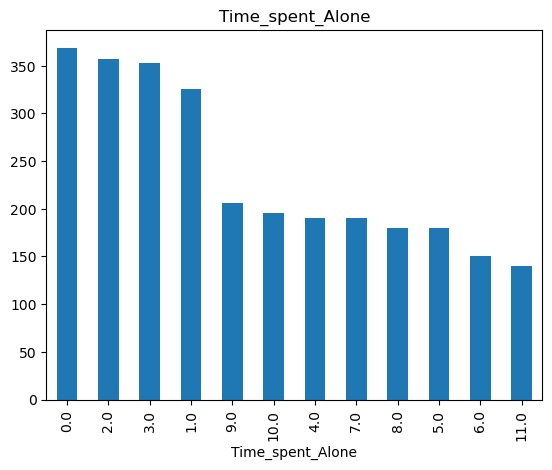

Column: Stage_fear


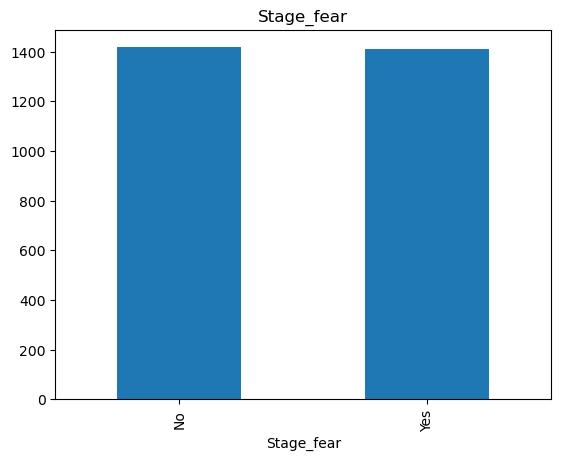

Column: Social_event_attendance


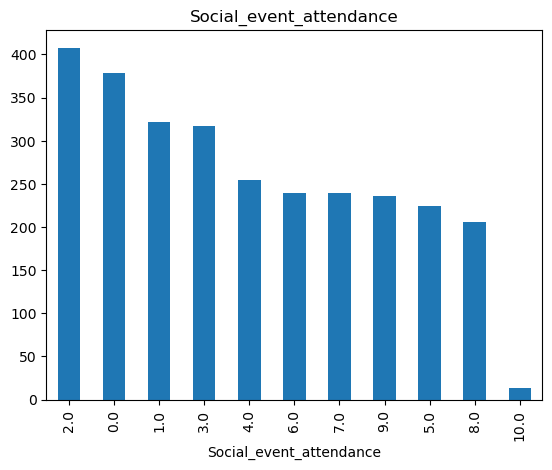

Column: Going_outside


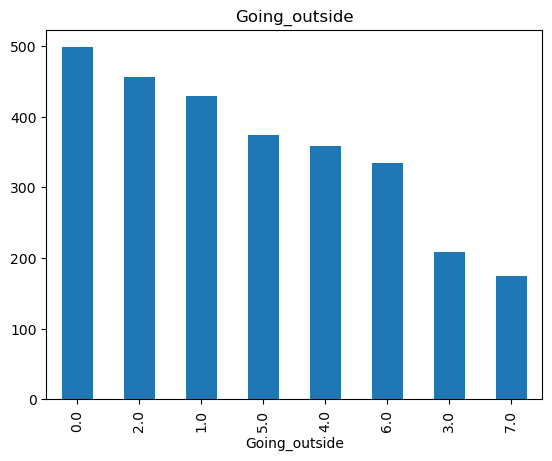

Column: Drained_after_socializing


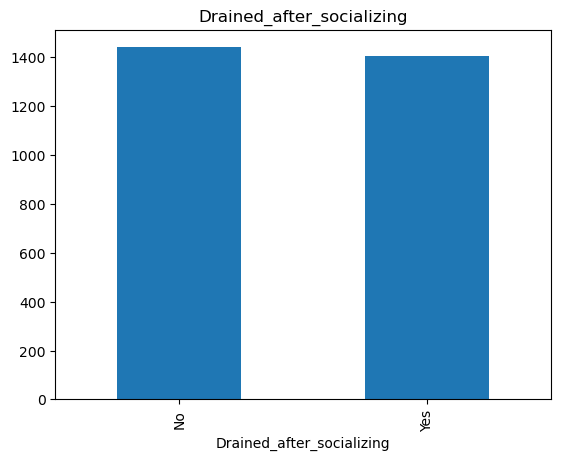

Column: Friends_circle_size


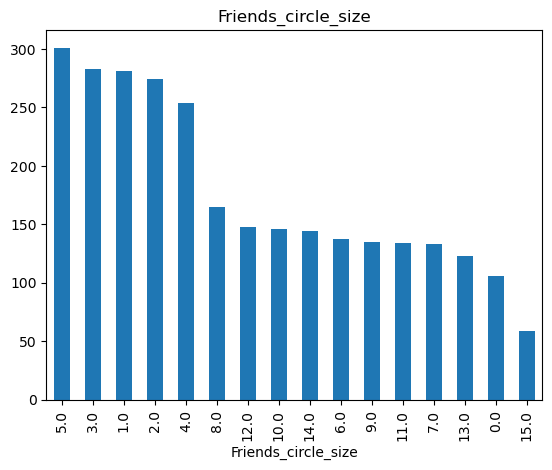

Column: Post_frequency


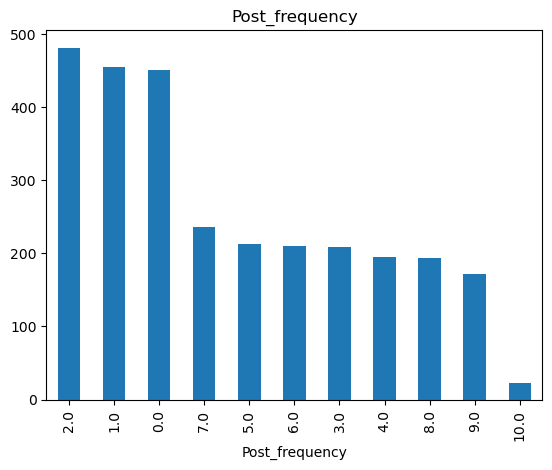

Column: Personality


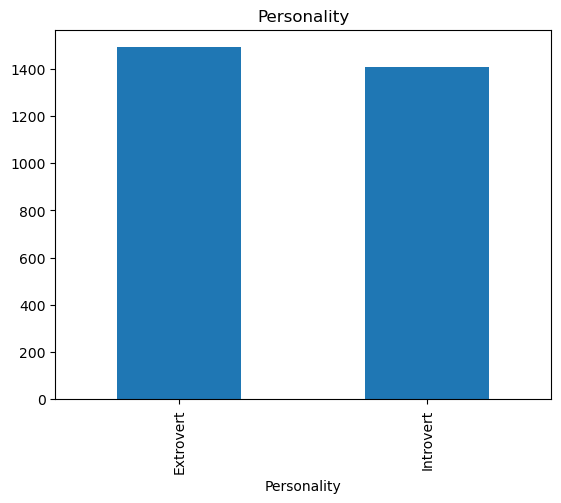

In [143]:
for col in df.columns:
    print(f"Column: {col}")
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

In [144]:
cat_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['number']).columns

print("Categorical Columns:", cat_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: Index(['Stage_fear', 'Drained_after_socializing', 'Personality'], dtype='object')
Numerical Columns: Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency'],
      dtype='object')


In [145]:
df.isna().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [146]:
df.shape

(2900, 8)

In [147]:
df = df.drop_duplicates(keep='first')
df.head()       

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [148]:
df.shape

(2512, 8)

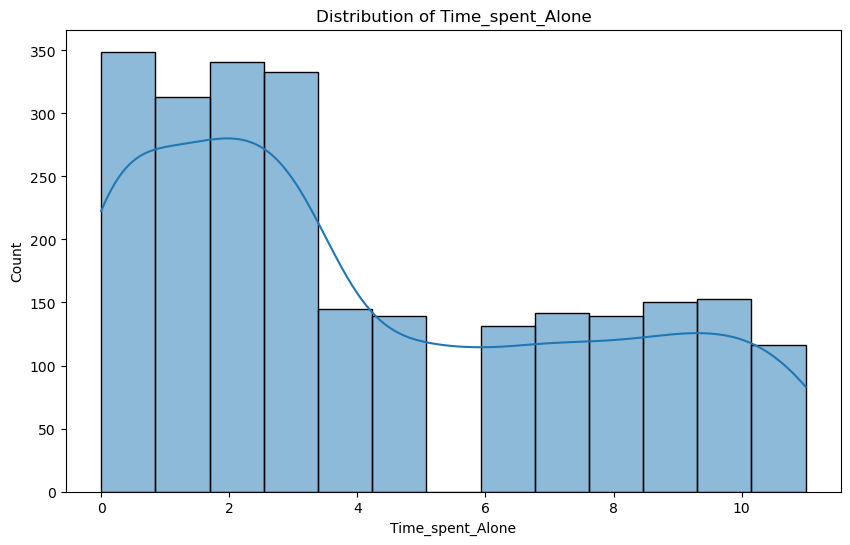

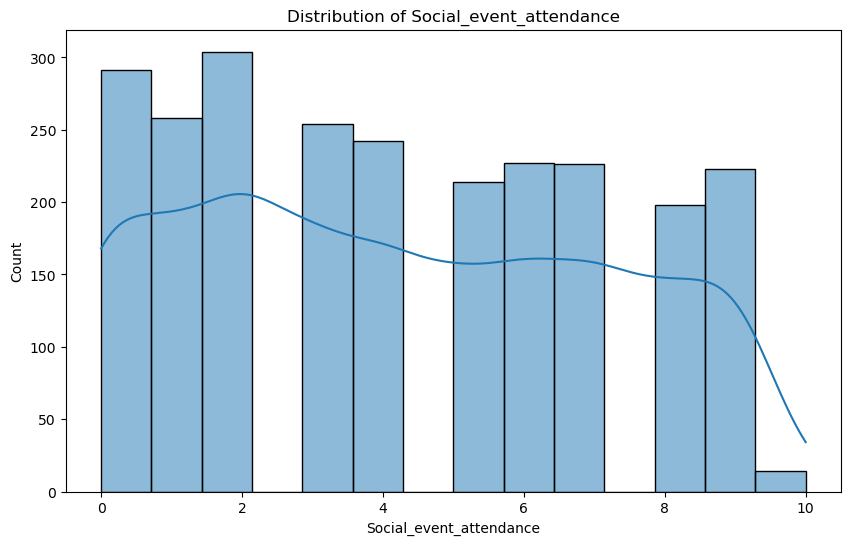

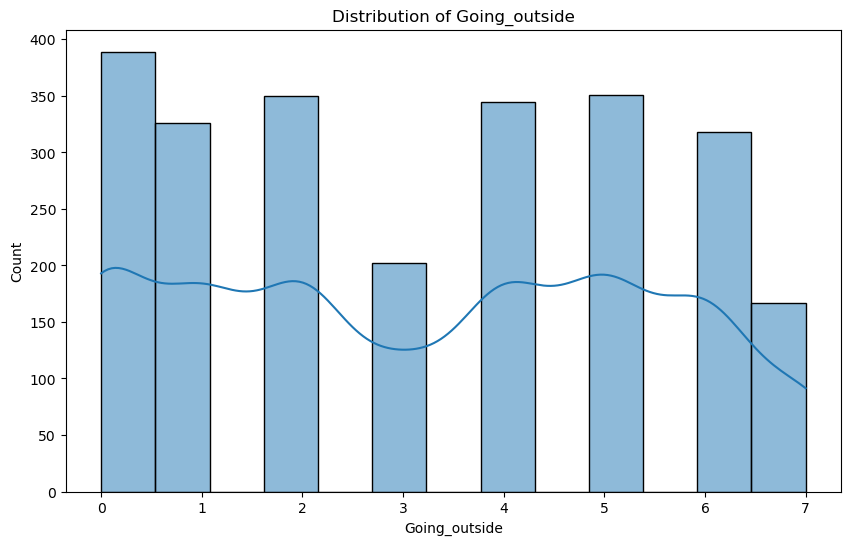

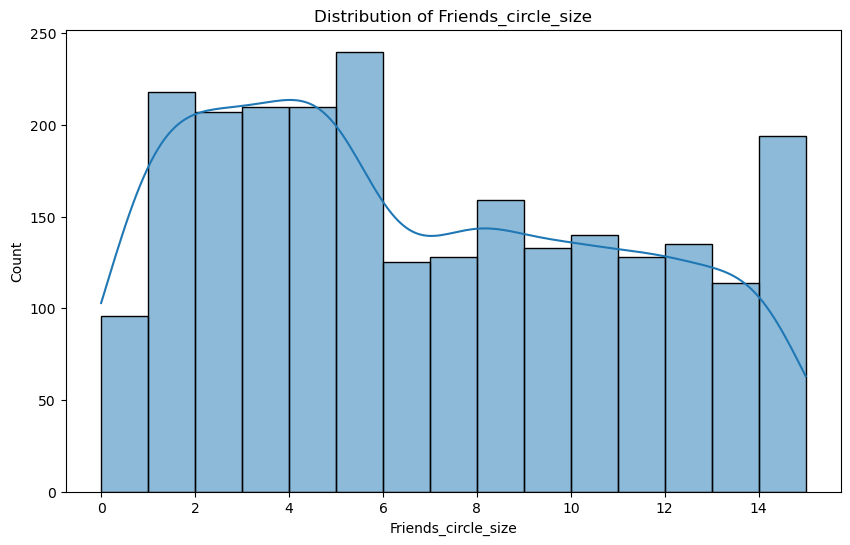

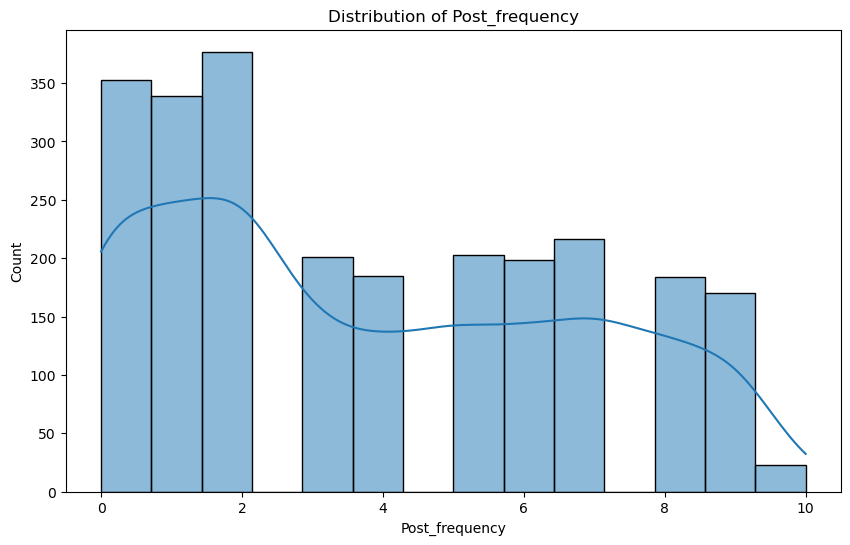

In [149]:
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [150]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [151]:
import pandas as pd
import numpy as np

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_count = len(outliers)
    outlier_pct = outlier_count / len(df) * 100

    outlier_summary.append([
        col,
        outlier_count,
        round(outlier_pct, 2),
        lower_bound,
        upper_bound
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier_Count", "Outlier_%", "Lower_Bound", "Upper_Bound"]
).sort_values("Outlier_%", ascending=False)

print(outlier_df)

                   Feature  Outlier_Count  Outlier_%  Lower_Bound  Upper_Bound
0         Time_spent_Alone              0        0.0         -8.0         16.0
1  Social_event_attendance              0        0.0         -5.5         14.5
2            Going_outside              0        0.0         -5.0         11.0
3      Friends_circle_size              0        0.0         -7.5         20.5
4           Post_frequency              0        0.0         -6.5         13.5


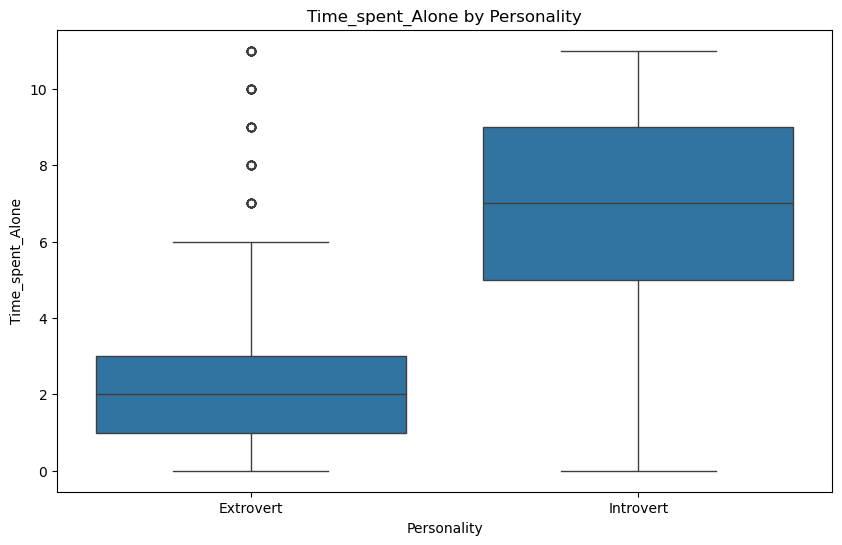

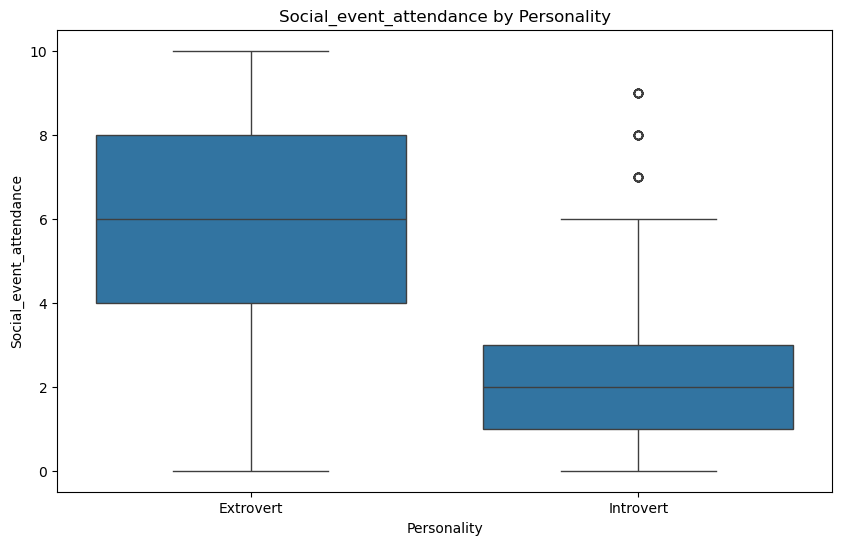

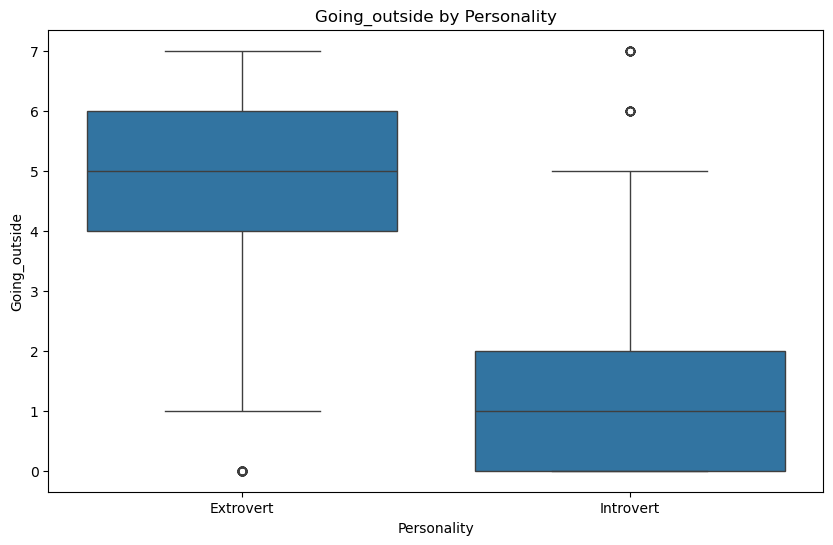

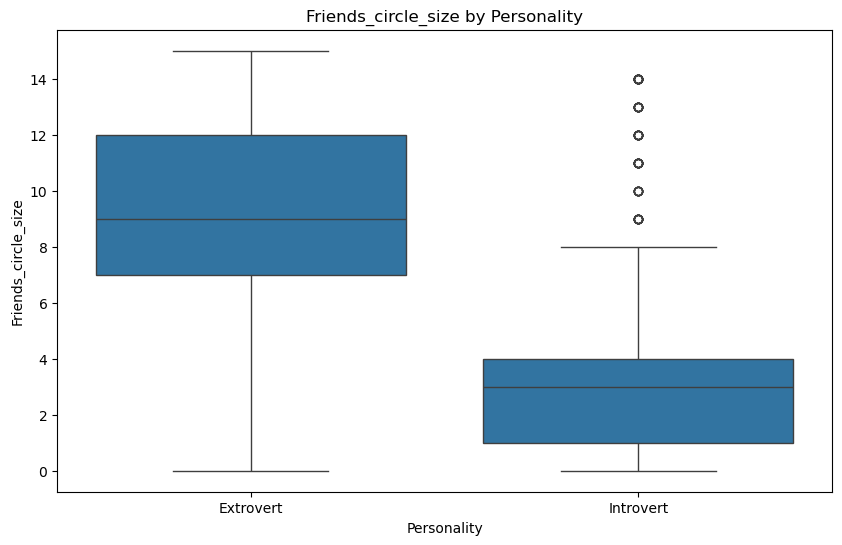

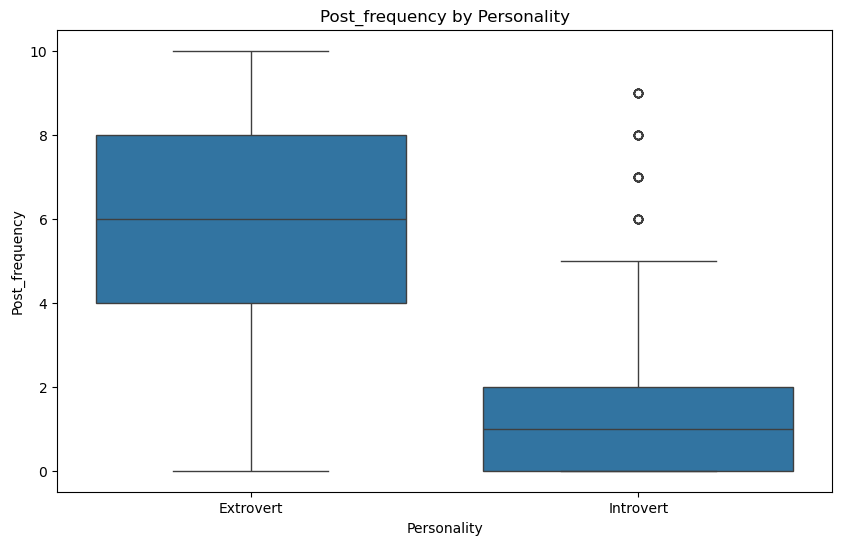

In [152]:
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=df['Personality'], y=col)
    plt.title(f'{col} by Personality')
    plt.show()

In [153]:
cor_matrix = df[numerical_columns].corr(method='pearson')
print(cor_matrix)

                         Time_spent_Alone  Social_event_attendance  \
Time_spent_Alone                 1.000000                -0.734429   
Social_event_attendance         -0.734429                 1.000000   
Going_outside                   -0.750646                 0.735150   
Friends_circle_size             -0.715215                 0.722290   
Post_frequency                  -0.725396                 0.727036   

                         Going_outside  Friends_circle_size  Post_frequency  
Time_spent_Alone             -0.750646            -0.715215       -0.725396  
Social_event_attendance       0.735150             0.722290        0.727036  
Going_outside                 1.000000             0.726263        0.756460  
Friends_circle_size           0.726263             1.000000        0.689838  
Post_frequency                0.756460             0.689838        1.000000  


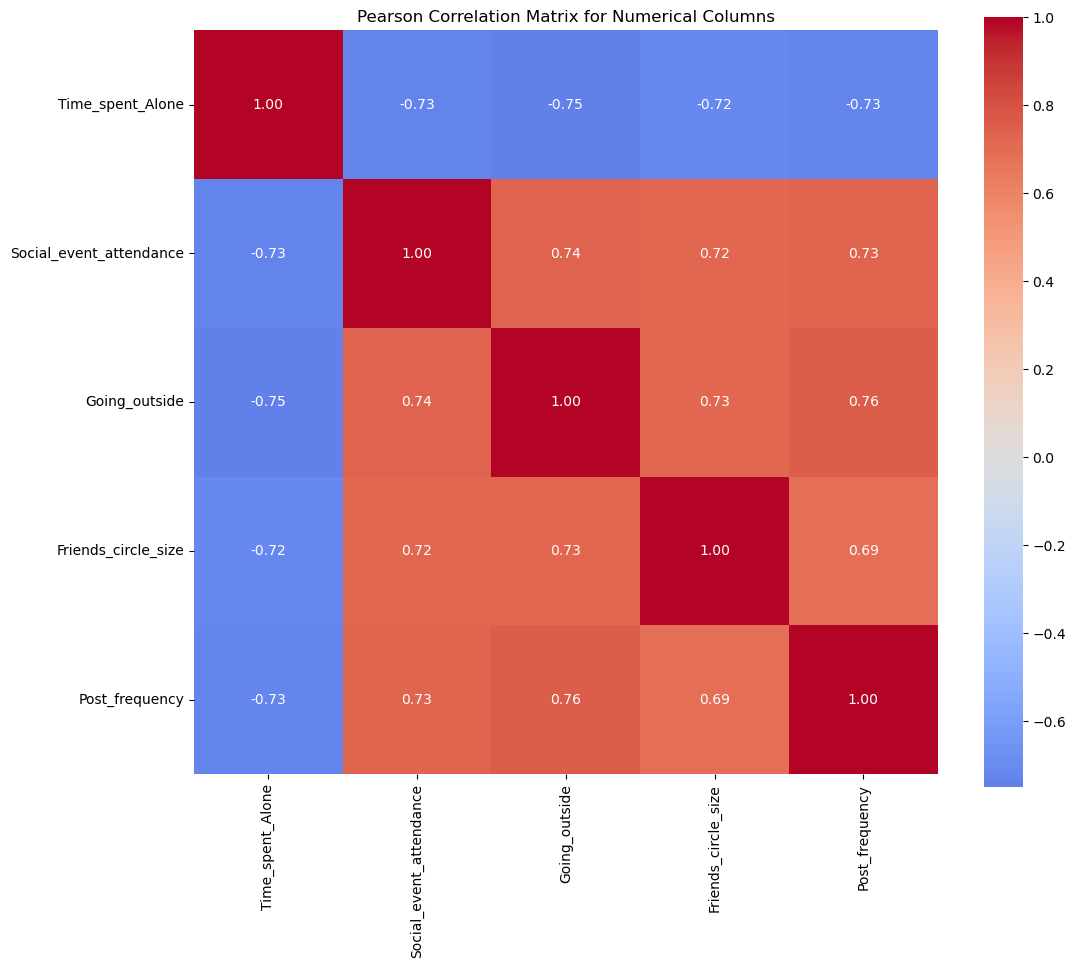

In [154]:
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Pearson Correlation Matrix for Numerical Columns')
plt.show()

In [155]:
df['target'] = df['Personality'].map({
    'Extrovert': 0,
    'Introvert': 1})
num_with_target = numerical_columns.tolist() + ['target']

spearman_matrix = df[num_with_target].corr(method='spearman')


print(spearman_matrix)

                         Time_spent_Alone  Social_event_attendance  \
Time_spent_Alone                 1.000000                -0.739825   
Social_event_attendance         -0.739825                 1.000000   
Going_outside                   -0.740247                 0.737199   
Friends_circle_size             -0.732574                 0.748771   
Post_frequency                  -0.742452                 0.749822   
target                           0.710694                -0.715172   

                         Going_outside  Friends_circle_size  Post_frequency  \
Time_spent_Alone             -0.740247            -0.732574       -0.742452   
Social_event_attendance       0.737199             0.748771        0.749822   
Going_outside                 1.000000             0.737045        0.766566   
Friends_circle_size           0.737045             1.000000        0.730495   
Post_frequency                0.766566             0.730495        1.000000   
target                       -0.714

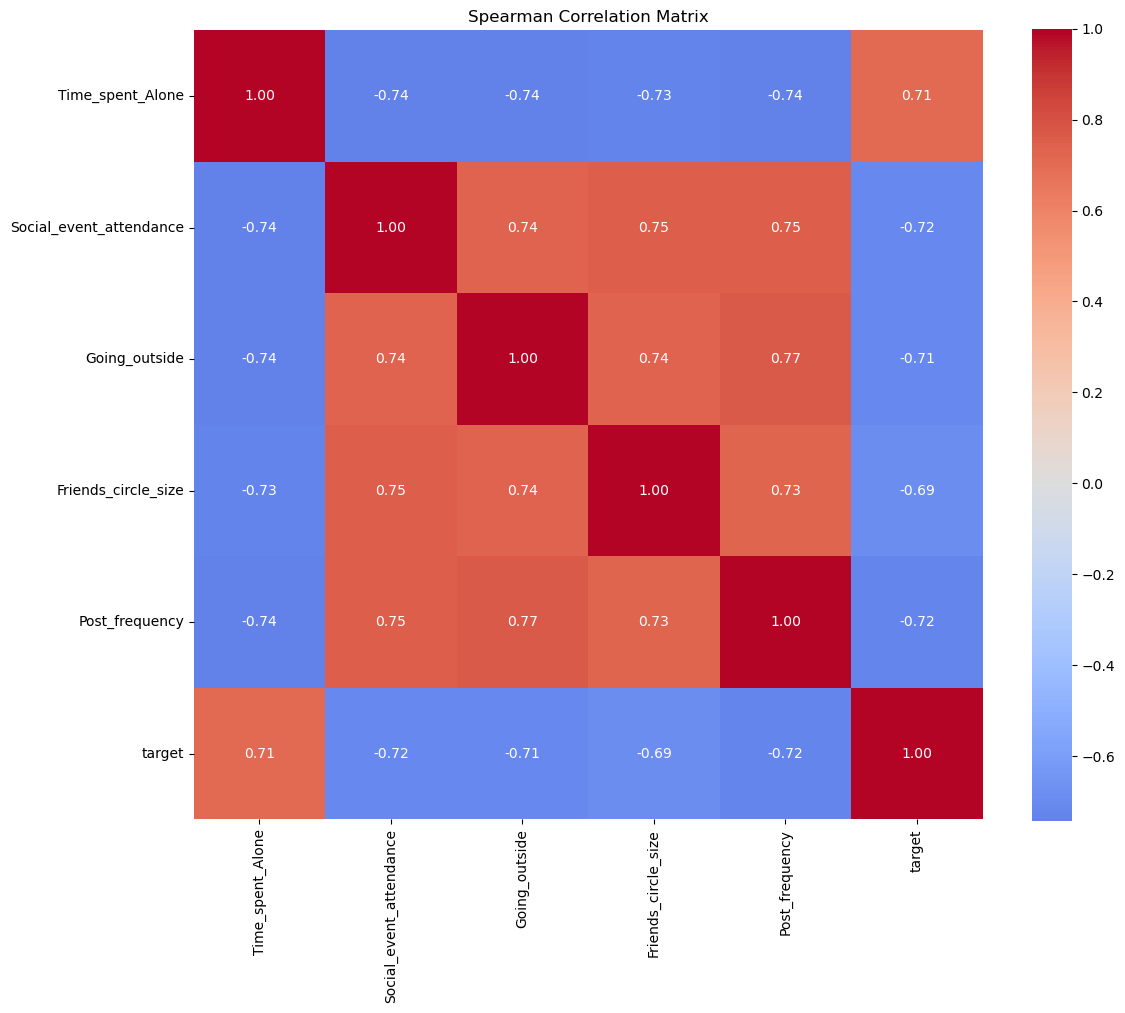

In [156]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [157]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    """
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    phi2 = chi2 / n

    # Bias correction
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Compute Cramér's V for each categorical feature vs target
results = []

for col in cat_columns:
    cv = cramers_v(df[col], df['target'])
    results.append([col, cv])

cramers_df = (
    pd.DataFrame(results, columns=['Feature', 'Cramers_V'])
      .sort_values('Cramers_V', ascending=False)
)

print(cramers_df)

                     Feature  Cramers_V
2                Personality   0.999190
1  Drained_after_socializing   0.848219
0                 Stage_fear   0.847209


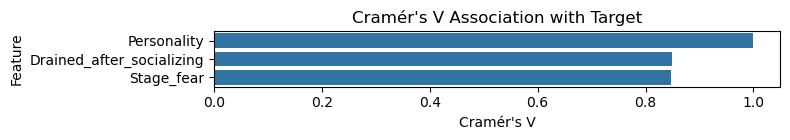

In [158]:
plt.figure(figsize=(8, len(cramers_df) * 0.5))

sns.barplot(
    data=cramers_df,
    x='Cramers_V',
    y='Feature'
)

plt.title("Cramér's V Association with Target")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [159]:
from scipy.stats import mannwhitneyu

target_col = 'target'

def rank_biserial(x, y):
    u, _ = mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    return 1 - (2*u) / (n1*n2)

results = []

for col in numerical_columns:
    g0 = df[df[target_col] == 0][col].dropna()
    g1 = df[df[target_col] == 1][col].dropna()

    rbc = rank_biserial(g0, g1)

    results.append([col, abs(rbc)])

rbc_df = pd.DataFrame(results, columns=["Feature", "Rank_Biserial"])
rbc_df = rbc_df.sort_values("Rank_Biserial", ascending=False)

print(rbc_df)

                   Feature  Rank_Biserial
4           Post_frequency       0.836626
1  Social_event_attendance       0.828936
2            Going_outside       0.824876
0         Time_spent_Alone       0.822659
3      Friends_circle_size       0.804017


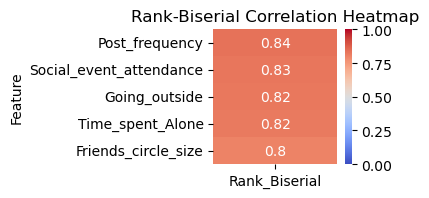

In [160]:
plt.figure(figsize=(2, len(rbc_df) * 0.35))

sns.heatmap(
    rbc_df.set_index("Feature"),
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Rank-Biserial Correlation Heatmap")
plt.show()

In [161]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality', 'target'],
      dtype='object')

In [162]:
df[cat_columns].nunique()

Stage_fear                   2
Drained_after_socializing    2
Personality                  2
dtype: int64

In [163]:
df['target'].value_counts(normalize=True)

target
0    0.564092
1    0.435908
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'Time_spent_Alone'}>,
        <Axes: title={'center': 'Social_event_attendance'}>],
       [<Axes: title={'center': 'Going_outside'}>,
        <Axes: title={'center': 'Friends_circle_size'}>],
       [<Axes: title={'center': 'Post_frequency'}>, <Axes: >]],
      dtype=object)

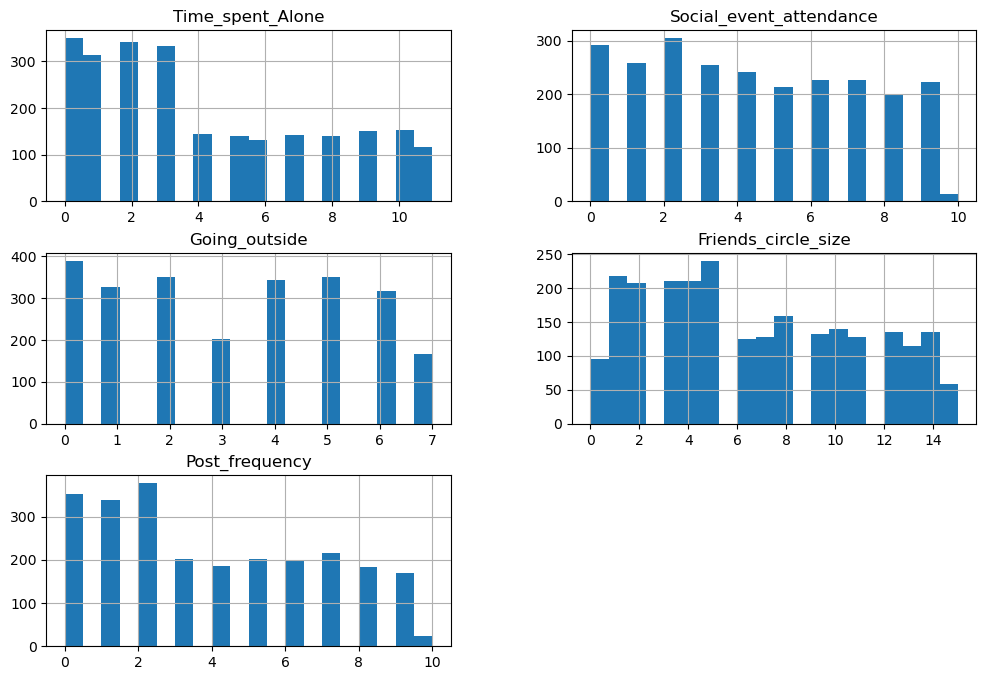

In [164]:
df[numerical_columns].hist(figsize=(12,8), bins=20)

target             0         1
Stage_fear                    
No          0.942136  0.057864
Yes         0.096242  0.903758


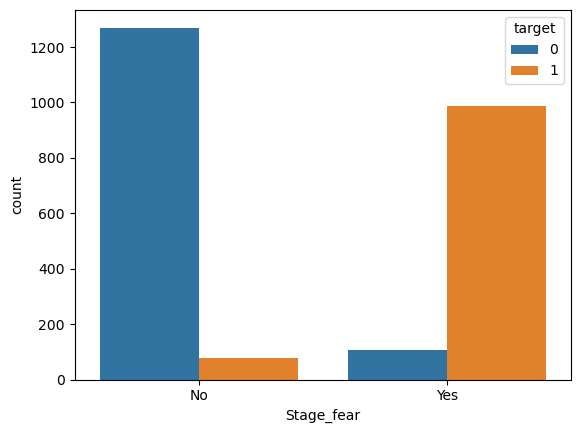

target                            0         1
Drained_after_socializing                    
No                         0.943149  0.056851
Yes                        0.096419  0.903581


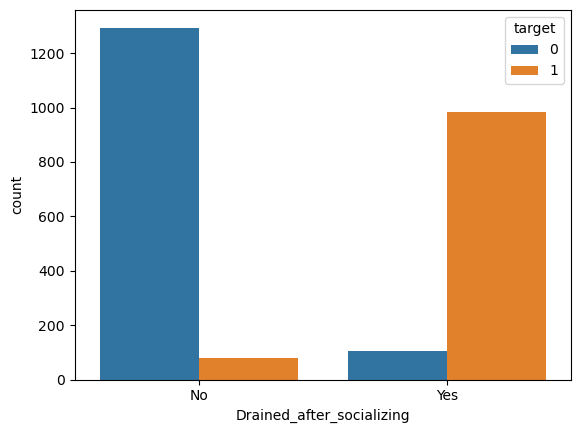

In [165]:
cat_cols = ['Stage_fear', 'Drained_after_socializing']

for col in cat_cols:
    print(pd.crosstab(df[col], df['target'], normalize='index'))
    sns.countplot(x=col, hue='target', data=df)
    plt.show()

In [166]:
# Null counts
null_counts = df.isnull().sum().sort_values(ascending=False)

# Null percentage
null_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

null_summary = pd.DataFrame({
    "Null_Count": null_counts,
    "Null_Percent": null_percent
})

print(null_summary)

                           Null_Count  Null_Percent
Friends_circle_size                75      2.985669
Stage_fear                         73      2.906051
Going_outside                      65      2.587580
Post_frequency                     63      2.507962
Time_spent_Alone                   61      2.428344
Social_event_attendance            61      2.428344
Drained_after_socializing          51      2.030255
Personality                         0      0.000000
target                              0      0.000000


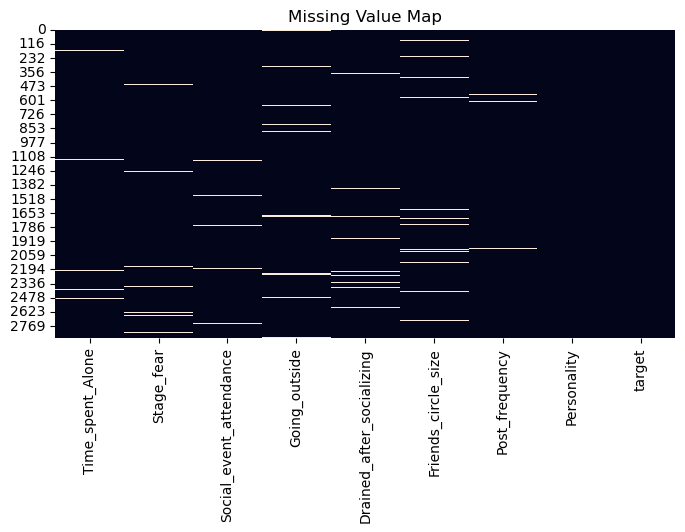

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Map")
plt.show()

In [168]:
df_imputed = df.copy()

# -----------------------
# NUMERIC: median impute
# -----------------------
for col in numerical_columns:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

# -----------------------
# CATEGORICAL: "Unknown"
# -----------------------
for col in cat_columns:
    df_imputed[col] = df_imputed[col].fillna("Unknown")

In [169]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ------------------------
# 1. Split features/target
# ------------------------
X = df_imputed.drop(columns=['Personality', 'target'])
y = df_imputed['target']

# ------------------------
# 2. Identify columns
# ------------------------
numeric_features = [
    'Time_spent_Alone',
    'Social_event_attendance',
    'Going_outside',
    'Friends_circle_size',
    'Post_frequency'
]

categorical_features = [
    'Stage_fear',
    'Drained_after_socializing'
]


In [170]:
from sklearn.model_selection import train_test_split

# 1) Split off the test set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Split the remaining data into train and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")

Train: 2009 rows
Validation: 251 rows
Test: 252 rows


In [171]:
# ------------------------
# 4. Preprocessing pipeline
# ------------------------
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    drop='first',          # avoids dummy trap
    handle_unknown='ignore'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [172]:
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [173]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time_spent_Alone',
                                                   'Social_event_attendance',
                                                   'Going_outside',
                                                   'Friends_circle_size',
                                                   'Post_frequency']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Stage_fear',
                                                   'Drained_after_socializing'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [174]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate(model, X_val, y_val, name):
    y_pred = model.predict(X_val)

    print(f"\n===== {name} =====")
    print("Validation Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred))

evaluate(log_reg_model, X_train, y_train, "Logistic Regression")
evaluate(rf_model, X_train, y_train, "Random Forest")


===== Logistic Regression =====
Validation Accuracy: 0.9298158287705326
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1133
           1       0.91      0.93      0.92       876

    accuracy                           0.93      2009
   macro avg       0.93      0.93      0.93      2009
weighted avg       0.93      0.93      0.93      2009


===== Random Forest =====
Validation Accuracy: 0.9815828770532603
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1133
           1       0.97      0.99      0.98       876

    accuracy                           0.98      2009
   macro avg       0.98      0.98      0.98      2009
weighted avg       0.98      0.98      0.98      2009



In [175]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate(model, X_val, y_val, name):
    y_pred = model.predict(X_val)

    print(f"\n===== {name} =====")
    print("Validation Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred))

evaluate(log_reg_model, X_val, y_val, "Logistic Regression")
evaluate(rf_model, X_val, y_val, "Random Forest")


===== Logistic Regression =====
Validation Accuracy: 0.896414342629482
              precision    recall  f1-score   support

           0       0.95      0.87      0.90       142
           1       0.84      0.94      0.89       109

    accuracy                           0.90       251
   macro avg       0.89      0.90      0.90       251
weighted avg       0.90      0.90      0.90       251


===== Random Forest =====
Validation Accuracy: 0.8685258964143426
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       142
           1       0.82      0.89      0.85       109

    accuracy                           0.87       251
   macro avg       0.87      0.87      0.87       251
weighted avg       0.87      0.87      0.87       251



In [176]:
df_imputed['social_activity_score'] = (
    df_imputed['Social_event_attendance'] +
    df_imputed['Going_outside'] +
    df_imputed['Post_frequency']
)

df_imputed['isolation_score'] = (
    df_imputed['Time_spent_Alone'] -
    df_imputed['Social_event_attendance']
)

df_imputed['social_fatigue_index'] = (
    df_imputed['Drained_after_socializing'].map({'Yes': 1, 'No': 0}) *
    df_imputed['Stage_fear'].map({'Yes': 1, 'No': 0})
)

df_imputed['social_confidence'] = (
    df_imputed['Friends_circle_size'] *
    df_imputed['Social_event_attendance']
)

df_imputed['online_vs_offline_ratio'] = (
    df_imputed['Post_frequency'] /
    (df_imputed['Going_outside'] + 1)
)

behavior_cols = [
    'Time_spent_Alone',
    'Social_event_attendance',
    'Going_outside',
    'Friends_circle_size',
    'Post_frequency'
]

df_imputed['behavior_variance'] = df_imputed[behavior_cols].var(axis=1)

df_imputed['alone_vs_friends'] = df_imputed['Time_spent_Alone'] / (df_imputed['Friends_circle_size'] + 1)
df_imputed['social_outing_density'] = df_imputed['Social_event_attendance'] * df_imputed['Going_outside']

In [177]:
df_imputed.dropna(inplace=True)

In [178]:
df_imputed.isnull().sum().sum()  # Check for any remaining missing values

np.int64(0)

In [179]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

baseline_metrics = {
    "Logistic Regression": accuracy_score(y_val, log_reg_model.predict(X_val)),
    "Random Forest": accuracy_score(y_val, rf_model.predict(X_val)),
}

base_numeric_features = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency",
]

engineered_features = [
    "social_activity_score",
    "isolation_score",
    "social_fatigue_index",
    "social_confidence",
    "online_vs_offline_ratio",
    "behavior_variance",
    "alone_vs_friends",
    "social_outing_density",
]

numeric_features_full = [
    col for col in base_numeric_features + engineered_features
    if col in df_imputed.columns
]

X_full = df_imputed.drop(columns=["Personality", "target"])
y_full = df_imputed["target"]

preprocessor_full = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_full),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

models_full = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_full),
        ("model", LogisticRegression(max_iter=1000)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_full),
        ("model", RandomForestClassifier(random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline validation accuracy:")
for name, acc in baseline_metrics.items():
    print(f"{name}: {acc:.4f}")

Baseline validation accuracy:
Logistic Regression: 0.8964
Random Forest: 0.8685


In [180]:
print("\nCross-validated accuracy using all rows with engineered features:")
for name, model in models_full.items():
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring="accuracy")
    print(f"{name}: mean CV accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

for name, model in models_full.items():
    model.fit(X_full, y_full)
    train_acc = accuracy_score(y_full, model.predict(X_full))
    print(f"{name} full-data training accuracy: {train_acc:.4f}")


Cross-validated accuracy using all rows with engineered features:
Logistic Regression: mean CV accuracy = 0.9234 +/- 0.0097
Random Forest: mean CV accuracy = 0.9012 +/- 0.0104
Logistic Regression full-data training accuracy: 0.9234
Random Forest full-data training accuracy: 0.9745


In [181]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [182]:
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', LogisticRegression(max_iter=1000))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [183]:
log_reg_grid = {
    'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000, 3000]
}

rf_grid = {
    'model__n_estimators': [100, 200, 500, 1000],

    'model__max_depth': [
        None,
        5,
        10,
        20,
        30
    ],

    'model__min_samples_split': [
        2,
        5,
        10,
        20
    ],

    'model__min_samples_leaf': [
        1,
        2,
        4,
        8
    ],

    'model__max_features': [
        'sqrt',
        'log2',
        None
    ],

    'model__bootstrap': [
        True,
        False
    ],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

xgb_grid = {
    'model__n_estimators': [
        100,
        200,
        500
    ],

    'model__max_depth': [
        3,
        5,
        7,
        10
    ],

    'model__learning_rate': [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    'model__subsample': [
        0.6,
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.6,
        0.8,
        1.0
    ],

    'model__gamma': [
        0,
        0.1,
        0.3,
        1
    ],

    'model__min_child_weight': [
        1,
        3,
        5,
        10
    ],

    'model__reg_alpha': [
        0,
        0.01,
        0.1,
        1
    ],

    'model__reg_lambda': [
        1,
        5,
        10,
        20
    ]
}

In [184]:
# 1) Split off the test set
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

# 2) Split the remaining data into train and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")

Train: 1911 rows
Validation: 239 rows
Test: 239 rows


In [185]:
grid_log_reg = GridSearchCV(
    log_reg_pipeline,
    log_reg_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_log_reg.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Time_spent_Alone',
                                                                          'Social_event_attendance',
                                                                          'Going_outside',
                                                                          'Friends_circle_size',
                                                                          'Post_frequency',
                                                                          'social_activity_score',
                                                                          'isolation_score',
                                                                          'social_fatigue_index',
                                                                          'social_confidence',
                                                                          'online_vs_offline_ratio',
                                                                          'behavior_variance',
                                                                          'a...
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Stage_fear',
                                                                          'Drained_after_socializing'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__max_iter': [1000, 3000],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear']},
             scoring='accuracy')

In [186]:
grid_rf = GridSearchCV(
    rf_pipeline,
    rf_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Time_spent_Alone',
                                                                          'Social_event_attendance',
                                                                          'Going_outside',
                                                                          'Friends_circle_size',
                                                                          'Post_frequency',
                                                                          'social_activity_score',
                                                                          'isolation_score',
                                                                          'social_fatigue_index',
                                                                          'social_confidence',
                                                                          'online_vs_offline_ratio',
                                                                          'behavior_variance',
                                                                          'a...
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__bootstrap': [True, False],
                         'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [None, 5, 10, 20, 30],
                         'model__max_features': ['sqrt', 'log2', None],
                         'model__min_samples_leaf': [1, 2, 4, 8],
                         'model__min_samples_split': [2, 5, 10, 20],
                         'model__n_estimators': [100, 200, 500, 1000]},
             scoring='accuracy')

In [187]:
grid_xgb = GridSearchCV(
    xgb_pipeline,
    xgb_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Time_spent_Alone',
                                                                          'Social_event_attendance',
                                                                          'Going_outside',
                                                                          'Friends_circle_size',
                                                                          'Post_frequency',
                                                                          'social_activity_score',
                                                                          'isolation_score',
                                                                          'social_fatigue_index',
                                                                          'social_confidence',
                                                                          'online_vs_offline_ratio',
                                                                          'behavior_variance',
                                                                          'a...
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.6, 0.8, 1.0],
                         'model__gamma': [0, 0.1, 0.3, 1],
                         'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'model__max_depth': [3, 5, 7, 10],
                         'model__min_child_weight': [1, 3, 5, 10],
                         'model__n_estimators': [100, 200, 500],
                         'model__reg_alpha': [0, 0.01, 0.1, 1],
                         'model__reg_lambda': [1, 5, 10, 20],
                         'model__subsample': [0.6, 0.8, 1.0]},
             scoring='accuracy')

In [188]:
best_log_reg = grid_log_reg.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

In [189]:
evaluate(best_log_reg, X_val, y_val, "Tuned Logistic Regression")
evaluate(best_rf, X_val, y_val, "Tuned Random Forest")
evaluate(best_xgb, X_val, y_val, "Tuned XGBoost")


===== Tuned Logistic Regression =====
Validation Accuracy: 0.9163179916317992
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       136
           1       0.89      0.92      0.90       103

    accuracy                           0.92       239
   macro avg       0.91      0.92      0.92       239
weighted avg       0.92      0.92      0.92       239


===== Tuned Random Forest =====
Validation Accuracy: 0.9163179916317992
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       136
           1       0.89      0.92      0.90       103

    accuracy                           0.92       239
   macro avg       0.91      0.92      0.92       239
weighted avg       0.92      0.92      0.92       239


===== Tuned XGBoost =====
Validation Accuracy: 0.9205020920502092
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       136
           1      

In [190]:
print(grid_log_reg.best_score_)
print(grid_rf.best_score_)
print(grid_xgb.best_score_)

print(grid_log_reg.best_params_)
print(grid_rf.best_params_)
print(grid_xgb.best_params_)

0.9225513649474391
0.9225513649474391
0.9235998523642228
{'model__C': 0.0001, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
{'model__bootstrap': True, 'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 20, 'model__n_estimators': 100}
{'model__colsample_bytree': 1.0, 'model__gamma': 0, 'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__min_child_weight': 10, 'model__n_estimators': 100, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 0.6}


In [191]:
import joblib

joblib.dump(grid_log_reg.best_estimator_, "best_logistic_regression.pkl")
joblib.dump(grid_rf.best_estimator_, "best_random_forest.pkl")
joblib.dump(grid_xgb.best_estimator_, "best_xgboost.pkl")

print("Best models saved successfully.")

Best models saved successfully.
